nltk — natural language toolkit 
 
 pymorphy2 —модуль, который позволяет работать с текстами  на русском языке

 itertools — модуль для работы с итераторами

Инфо из гпт: https://www.perplexity.ai/search/1-rassmotrite-noutbuk-text-rec-RQwRYqZMTi2StiqKuYuyrA#19


In [173]:

import sqlalchemy
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import nltk
from nltk.corpus import stopwords

from sklearn.svm import LinearSVC

#from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier

from sklearn import metrics
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer, HashingVectorizer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split

import itertools

In [174]:
pip install pymorphy2

Note: you may need to restart the kernel to use updated packages.


You should consider upgrading via the 'C:\Users\MaxxPC\AppData\Local\Programs\Python\Python39\python.exe -m pip install --upgrade pip' command.


# Новый раздел

In [175]:
import pymorphy2

In [176]:
db=sqlalchemy.create_engine('sqlite:///books_db.sqlite')
df=pd.read_sql_query('select * from chunk', db, index_col='chunk_id')
db.dispose()
df.head()

,author,book_id,text
chunk_id,,,
1,Иван Алексеевич Бунин,1,"В знак веры в жизнь вечную, в воскресение из м..."
2,Иван Алексеевич Бунин,1,"Ибо он, этот волчец, воистину чудесен. Сорванн..."
3,Иван Алексеевич Бунин,1,"Так утешаюсь и я, воскрешая в себе те светонос..."
4,Иван Алексеевич Бунин,1,"Роза Иерихона. В живую воду сердца, в чистую в..."
5,Иван Алексеевич Бунин,1,"Золотилось солнце на востоке, за туманной синь..."


is_cyr_word —  функция, которая проверяет, написано ли это слово на кириллице

process_text — это функция, которая занимается препроцессингом, предобработкой текста

При помощи функции wordpunct_tokenize модуля nltk текст разделяется на отдельные токены — слова


In [177]:
morph=pymorphy2.MorphAnalyzer()
def is_cyr_word(word):
    for ch in word:
        if not ('а' <= ch <= 'я'):
            return False
    return True
def process_text(text):        
    lower = (word.lower() for word in nltk.wordpunct_tokenize(text))
    cyr = (word for word in lower if  is_cyr_word(word))
    norm_form = (morph.parse(word)[0].normal_form for word in cyr)
    return ' '.join(norm_form)
  
def shorten_name(name):
  splited = name.split(' ')
  if len(splited) != 3:
    return name
  i,o,f=splited
  return '%s.%s.%s' % (i[0], o[0], f)



2025-11-16 22:53:43,608 ; INFO; Loading dictionaries from C:\Users\MaxxPC\AppData\Local\Programs\Python\Python39\lib\site-packages\pymorphy2_dicts_ru\data
2025-11-16 22:53:43,660 ; INFO; format: 2.4, revision: 417127, updated: 2020-10-11T15:05:51.070345


In [178]:
df['words']=df['text'].map(process_text)


In [179]:
df['author']=df['author'].map(shorten_name)


In [180]:
df.to_csv('texts_temp.csv',index=False)
df.head()

,author,book_id,text,words
chunk_id,,,,
1,И.А.Бунин,1,"В знак веры в жизнь вечную, в воскресение из м...",в знак вера в жизнь вечный в воскресение из мё...
2,И.А.Бунин,1,"Ибо он, этот волчец, воистину чудесен. Сорванн...",ибо он этот волчец воистину чудесный сорвать и...
3,И.А.Бунин,1,"Так утешаюсь и я, воскрешая в себе те светонос...",так утешаться и я воскрешать в себя тот светон...
4,И.А.Бунин,1,"Роза Иерихона. В живую воду сердца, в чистую в...",роза иерихон в живой вода сердце в чистый влаг...
5,И.А.Бунин,1,"Золотилось солнце на востоке, за туманной синь...",золотиться солнце на восток за туманный синь д...


In [181]:
df=pd.read_csv('texts_temp.csv').dropna()
df[['author','text']].groupby(['author']).count()

,text
author,
А.П.Платонов,11019
А.П.Чехов,4359
А.С.Пушкин,516
Б.Л.Пастернак,2285
И.А.Бунин,2490
И.А.Гончаров,11659
И.С.Тургенев,6296
Л.Н.Толстой,4515
Н.В.Гоголь,1112


Скачиваем стоп-слова...

In [182]:
nltk.download("stopwords")

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\MaxxPC\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

..на русском языке

In [183]:
ru_stop_words= stopwords.words('russian')

In [184]:
print(ru_stop_words[0:50])

['и', 'в', 'во', 'не', 'что', 'он', 'на', 'я', 'с', 'со', 'как', 'а', 'то', 'все', 'она', 'так', 'его', 'но', 'да', 'ты', 'к', 'у', 'же', 'вы', 'за', 'бы', 'по', 'только', 'ее', 'мне', 'было', 'вот', 'от', 'меня', 'еще', 'нет', 'о', 'из', 'ему', 'теперь', 'когда', 'даже', 'ну', 'вдруг', 'ли', 'если', 'уже', 'или', 'ни', 'быть']


In [185]:
train, test = train_test_split(df, test_size=0.33)

создаем объект TfidfVectorizer и линейный классификатор LinearSVC

In [186]:
tf_idf=TfidfVectorizer(max_df=0.5, min_df=3,stop_words=ru_stop_words)
clf=LinearSVC()
tf_idf
clf

LinearSVC()

задаем пайплайн

In [187]:
pipeline=Pipeline([
    ('tf_idf',tf_idf),
    ('clf',clf)])
pipeline

Pipeline(steps=[('tf_idf',
                 TfidfVectorizer(max_df=0.5, min_df=3,
                                 stop_words=['и', 'в', 'во', 'не', 'что', 'он',
                                             'на', 'я', 'с', 'со', 'как', 'а',
                                             'то', 'все', 'она', 'так', 'его',
                                             'но', 'да', 'ты', 'к', 'у', 'же',
                                             'вы', 'за', 'бы', 'по', 'только',
                                             'ее', 'мне', ...])),
                ('clf', LinearSVC())])

In [188]:
parameters = {
    'tf_idf__max_df': [0.5, 0.7, 0.9],
    'tf_idf__min_df': [3, 5, 7],
    'clf__C': [0.1, 1, 10]
}

from sklearn.model_selection import GridSearchCV
grid = GridSearchCV(pipeline, parameters, scoring='f1_micro', cv=3)
grid.fit(train['words'], train['author'])
print('Лучшие параметры:', grid.best_params_)
print('F1-score:', grid.best_score_)


Лучшие параметры: {'clf__C': 1, 'tf_idf__max_df': 0.5, 'tf_idf__min_df': 3}
F1-score: 0.8646744856494898


In [189]:
def plot_confusion_matrix(cm,classes,title='Confusion matrix',cmap=plt.cm.Greens):
  plt.figure(figsize=(20,10))

  cm=cm.astype('float')/cm.sum(axis=1)[:,np.newaxis]*100
  plt.imshow(cm,interpolation='nearest',cmap=cmap)
  plt.title(title)
  plt.colorbar()
  tick_marks=np.arange(len(classes))
  plt.xticks(tick_marks,classes, rotation=45)
  plt.yticks(tick_marks,classes)

  thresh=cm.max()/2.
  for i,j in itertools.product(range(cm.shape[0],cm.shape[1],)):
    plt.text(i,j,'%.2f%%' % cm[i,j], horizontalalignment='center',color='black')
  plt.tight_layout()
  plt.ylabel('True label')
  plt.xlabel('Predicted label')









In [190]:
def pipe(clf, train, test):
  clf.fit(train['words'],train['author'])

  pred=clf.predict(test['words'])
  score=metrics.f1_score(test['author'], pred, average='micro')
  authors=list(train['author'].unique())
  cm=metrics.confusion_matrix(test['author'], pred,labels=authors)
  plt.figure(figsize=(20,10))
  plot_confusion_matrix(cm, authors)

  return clf, score



F_score 0.8921146736165828


<Figure size 2000x1000 with 0 Axes>

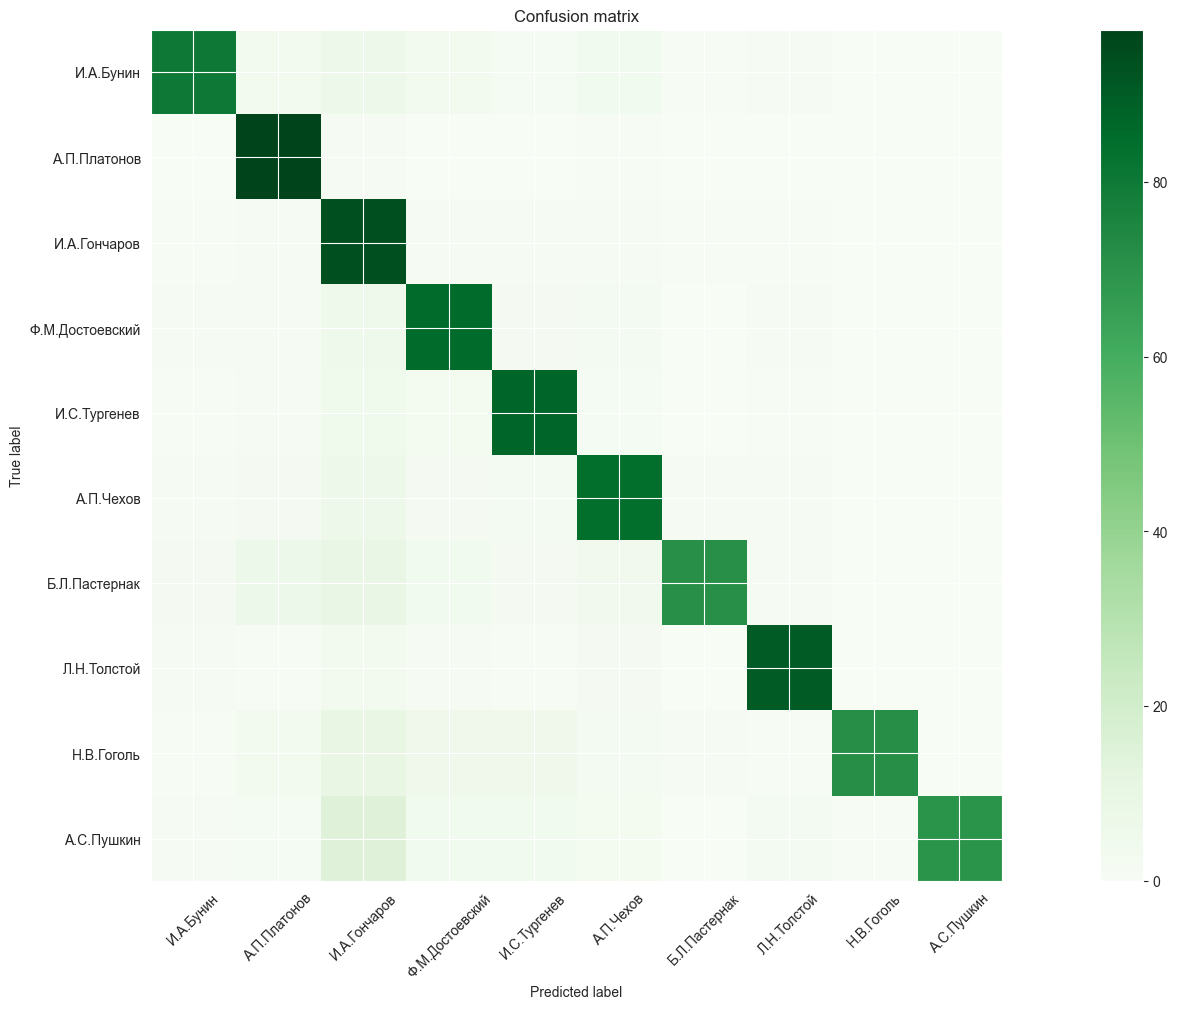

In [191]:
clf, score = pipe(pipeline,train,test)
print('F_score',score)
plt.show()

**WordToVec**

Разобьем текст на предложения

In [192]:
nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\MaxxPC\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\MaxxPC\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [193]:
tokenizer=nltk.data.load('tokenizers/punkt/english.pickle')


In [194]:
def chunk_to_sentences(text):
  raw_sentences=tokenizer.tokenize(text.strip())
  sentences=[]
  for sentence in raw_sentences:
    lower=(word.lower() for word in nltk.wordpunct_tokenize(sentence))
    cyr = (word for word in lower if  is_cyr_word(word))
    norm_form = list(morph.parse(word)[0].normal_form for word in cyr)
    if len(norm_form)>0:
      sentences.append(norm_form)
  return sentences

In [195]:
df['sentences']=df['text'].map(chunk_to_sentences)

In [196]:
rows=[]
for i, row in df.iterrows():
  for sent in row.sentences:
    new_row=[' '.join(sent)]
    new_row.extend(row.tolist()[:-1])
    rows.append(new_row )

In [197]:
df_sent=pd.DataFrame(rows,columns=['sentences','author','id','test','words'])
df_sent.to_csv('with_sentences.csv',index=False)
df_sent

,sentences,author,id,test,words
0,в знак вера в жизнь вечный в воскресение из мё...,И.А.Бунин,1,"В знак веры в жизнь вечную, в воскресение из м...",в знак вера в жизнь вечный в воскресение из мё...
1,странно что назвать роза да ещё роза иерихон э...,И.А.Бунин,1,"В знак веры в жизнь вечную, в воскресение из м...",в знак вера в жизнь вечный в воскресение из мё...
2,ибо он этот волчец воистину чудесный,И.А.Бунин,1,"Ибо он, этот волчец, воистину чудесен. Сорванн...",ибо он этот волчец воистину чудесный сорвать и...
3,сорвать и унести странник за тысяча верста от ...,И.А.Бунин,1,"Ибо он, этот волчец, воистину чудесен. Сорванн...",ибо он этот волчец воистину чудесный сорвать и...
4,но быть положить в вода тотчас начинать распус...,И.А.Бунин,1,"Ибо он, этот волчец, воистину чудесен. Сорванн...",ибо он этот волчец воистину чудесный сорвать и...
...,...,...,...,...,...
227315,любимый поговорка а вот позволить я сичас сича...,И.С.Тургенев,47,"С одной стороны рта зубов нет, так что все лиц...",с один сторона рот зуб нет так что всё лицо не...
227316,рука назад как приказать,И.С.Тургенев,47,"С одной стороны рта зубов нет, так что все лиц...",с один сторона рот зуб нет так что всё лицо не...
227317,трус естественный,И.С.Тургенев,47,"С одной стороны рта зубов нет, так что все лиц...",с один сторона рот зуб нет так что всё лицо не...
227318,я взять с себя когда послать он харлов,И.С.Тургенев,47,"С одной стороны рта зубов нет, так что все лиц...",с один сторона рот зуб нет так что всё лицо не...


In [198]:
df_sent=pd.read_csv('with_sentences.csv')

In [199]:
import gensim

In [211]:
num_features=500
context=5
min_word_count=3
num_workers=6
from gensim.models import word2vec

In [212]:
import logging

In [213]:
logging.basicConfig(format='%(asctime)s ; %(levelname)s; %(message)s',  level=logging.INFO)

In [214]:
print('Training model')
model=word2vec.Word2Vec([s.split(' ') for s in df_sent['sentences'].values],workers=num_workers, vector_size=num_features,min_count=min_word_count,window=context)


2025-11-16 23:24:19,700 ; INFO; collecting all words and their counts
2025-11-16 23:24:19,701 ; INFO; PROGRESS: at sentence #0, processed 0 words, keeping 0 word types
2025-11-16 23:24:19,724 ; INFO; PROGRESS: at sentence #10000, processed 147056 words, keeping 12452 word types
2025-11-16 23:24:19,742 ; INFO; PROGRESS: at sentence #20000, processed 257660 words, keeping 17177 word types


Training model


2025-11-16 23:24:19,761 ; INFO; PROGRESS: at sentence #30000, processed 375709 words, keeping 20194 word types
2025-11-16 23:24:19,780 ; INFO; PROGRESS: at sentence #40000, processed 482450 words, keeping 22505 word types
2025-11-16 23:24:19,797 ; INFO; PROGRESS: at sentence #50000, processed 593276 words, keeping 24310 word types
2025-11-16 23:24:19,816 ; INFO; PROGRESS: at sentence #60000, processed 710502 words, keeping 26919 word types
2025-11-16 23:24:19,833 ; INFO; PROGRESS: at sentence #70000, processed 804102 words, keeping 28053 word types
2025-11-16 23:24:19,854 ; INFO; PROGRESS: at sentence #80000, processed 946445 words, keeping 30794 word types
2025-11-16 23:24:19,871 ; INFO; PROGRESS: at sentence #90000, processed 1069157 words, keeping 32583 word types
2025-11-16 23:24:19,888 ; INFO; PROGRESS: at sentence #100000, processed 1184899 words, keeping 33521 word types
2025-11-16 23:24:19,903 ; INFO; PROGRESS: at sentence #110000, processed 1301556 words, keeping 35663 word ty

Заменим исходные векторы нормализованными. После этого модель будет работать быстрее, но огбучать ее уже нельзя.

In [215]:
model.init_sims(replace=True)

C:\Users\MaxxPC\AppData\Local\Temp\ipykernel_20520\3625671219.py:1: DeprecationWarning: Call to deprecated `init_sims` (Gensim 4.0.0 implemented internal optimizations that make calls to init_sims() unnecessary. init_sims() is now obsoleted and will be completely removed in future versions. See https://github.com/RaRe-Technologies/gensim/wiki/Migrating-from-Gensim-3.x-to-4).
  model.init_sims(replace=True)
2025-11-16 23:24:27,628 ; WARNING; destructive init_sims(replace=True) deprecated & no longer required for space-efficiency


In [216]:
model_name='150Features_Scontext'
model.save(model_name)


2025-11-16 23:24:29,061 ; INFO; Word2Vec lifecycle event {'fname_or_handle': '150Features_Scontext', 'separately': 'None', 'sep_limit': 10485760, 'ignore': frozenset(), 'datetime': '2025-11-16T23:24:29.061185', 'gensim': '4.4.0', 'python': '3.9.12 (tags/v3.9.12:b28265d, Mar 23 2022, 23:52:46) [MSC v.1929 64 bit (AMD64)]', 'platform': 'Windows-10-10.0.26100-SP0', 'event': 'saving'}
2025-11-16 23:24:29,062 ; INFO; storing np array 'vectors' to 150Features_Scontext.wv.vectors.npy
2025-11-16 23:24:29,101 ; INFO; storing np array 'syn1neg' to 150Features_Scontext.syn1neg.npy
2025-11-16 23:24:29,134 ; INFO; not storing attribute cum_table
2025-11-16 23:24:29,147 ; INFO; saved 150Features_Scontext


In [217]:
print('лишний: мать кот собака лошадь: ' + model.wv.doesnt_match('мать кот собака лошадь'.split()))
print('лишний: кастрюля кот собака лошадь: ' + model.wv.doesnt_match('кастрюля кот собака лошадь'.split()))
print('лишний: киборг кот собака лошадь: ' + model.wv.doesnt_match('киборг кот собака лошадь'.split()))
print('лишний: франция москва петербург париж: ' + model.wv.doesnt_match('франция москва петербург париж'.split()))

2025-11-16 23:24:34,598 ; WARNING; vectors for words {'киборг'} are not present in the model, ignoring these words


лишний: мать кот собака лошадь: мать
лишний: кастрюля кот собака лошадь: лошадь
лишний: киборг кот собака лошадь: кот
лишний: франция москва петербург париж: франция


In [218]:
print( str(model.wv.similar_by_word('отец')))

[('мать', 0.8891054391860962), ('жена', 0.8583924770355225), ('сын', 0.8273526430130005), ('муж', 0.8237420916557312), ('родный', 0.8186113834381104), ('сестра', 0.8053246140480042), ('дочь', 0.7557789087295532), ('тётка', 0.7460777759552002), ('брат', 0.745843231678009), ('ребёнок', 0.7330487966537476)]


In [208]:
print( str(model.wv.similar_by_vector('жена')))

[('муж', 0.910589873790741), ('отец', 0.8629423975944519), ('сестра', 0.8547850251197815), ('сын', 0.84958815574646), ('дочь', 0.8146281838417053), ('брат', 0.7985532283782959), ('мать', 0.7978643774986267), ('жених', 0.7454141974449158), ('тётка', 0.7336167693138123), ('родитель', 0.7283440828323364)]


In [209]:
print( str(model.wv.similar_by_vector('корабль')))

[('остров', 0.8799407482147217), ('завод', 0.8755621314048767), ('избушка', 0.8689128160476685), ('судно', 0.865981936454773), ('пароход', 0.8598302006721497), ('луг', 0.8572423458099365), ('батарея', 0.8545531630516052), ('роща', 0.8458797335624695), ('пруд', 0.8402689099311829), ('север', 0.8381682634353638)]


In [210]:
print( str(model.wv.similar_by_word('корабль')))

[('остров', 0.8799407482147217), ('завод', 0.8755621314048767), ('избушка', 0.8689128160476685), ('судно', 0.865981936454773), ('пароход', 0.8598302006721497), ('луг', 0.8572423458099365), ('батарея', 0.8545531630516052), ('роща', 0.8458797335624695), ('пруд', 0.8402689099311829), ('север', 0.8381682634353638)]
